<h1>The Correlation Between Time Spent on Social Media and Sleep Among Students</h1>

<h2>1. Business understanding</h2>

"How does the time spent on social media affect the amount of sleep?", this is the question we are eager to research and answer.

The effect of social media on sleep, academic performance and mental health has garnered a lot of research and discussion during the past years. Based on this dataset https://www.kaggle.com/datasets/harishyadav0506/impact-of-social-media-on-life that consists of data gathered from high school, undergraduate and postgraduate students on their social media and sleeping habits, academic performance and mental health, we aim to study the correlation between sleep and academic performance, and whether the type of social media has any impact on those two metrics. 

The scope of this study is limited to the dataset in question. It serves to find possible correlations between the subjects, which if found, could indicate further study on the matter.

<h2>2. Data understanding</h2>

In [37]:
import numpy as np
import pandas as pd

In [39]:
df_full = pd.read_csv("../datasets/Social_media_impact_on_life.csv")
df_full.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


In [41]:
df_full.dtypes

Student_ID                      object
Age                              int64
Gender                          object
Academic_Level                  object
Primary_Platform                object
Daily_Usage_Hours              float64
Weekend_Extra_Hours            float64
Device_Type                     object
Sleep_Duration_Hours           float64
Sleep_Quality_Score              int64
Late_Night_Usage                  bool
Social_Comparison_Frequency     object
Perceived_Stress_Score         float64
Mental_Health_Index              int64
Academic_Performance_GPA       float64
Overall_Impact                  object
dtype: object

The dataset has 16 metrics, student id included. The different metrics and their types are as follows:

| Feature Name | Type | Description |
| :- | -: | :-: |
| Student_ID | String | Unique identifier for each participant
| Age | Integer | Participant age (15 to 26 years)
| Gender | String | Self-reported gender category
| Academic_Level | String | High School, Undergraduate, or Postgraduate
| Primary_Platform | String | Most frequently consumed digital platform
| Daily_Usage_Hours | Float | Average daily social media screen time (hours)
| Weekend_Extra_Hours | Float | Supplementary screen time during weekends
| Device_Type | String | Primary device used for access
| Sleep_Duration_Hours | Float | Average nightly sleep duration
| Sleep_Quality_Score | Integer | Self-rated sleep quality (1 to 5 scale)
| Late_Night_Usage | Boolean | Frequent screen time past midnight
| Social_Comparison_Frequency | Categorical (String) | Frequency of social comparison behaviors (Never, Rarely, Sometimes, Frequently, Always)
| Perceived_Stress_Score | Float | PSS psychometric stress indicator (0 to 40)
| Mental_Health_Index | Integer | Composite well-being metric (10 to 98)
| Academic_Performance_GPA | Float | Cumulative GPA (Scale: 1.70 to 4.00)
| Overall_Impact | Categorical (String) | Multi-factor classification outcome (Beneficial, Neutral, Negative)

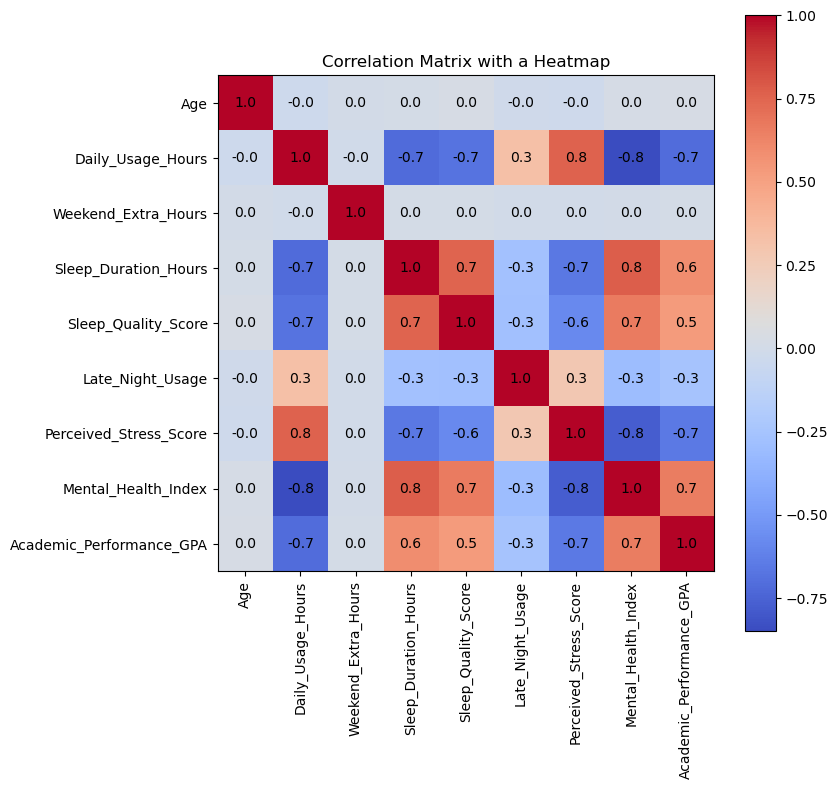

In [44]:
import matplotlib.pyplot as plt

correlation_matrix = df_full.corr(numeric_only=True)

plt.figure(figsize=(8, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.1f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix with a Heatmap')
plt.show()

plt.show()

Based on the correlation heatmap, <b>"Daily_Usage_Hours" (-0.7)</b>, <b>Perceived_Stress_Score, (-0.7)</b>, and <b>Late_Night_Usage (-0.3)</b> have the strongest <b>negative correlation</b> with sleep duration.

Conversely, <b>"mental health index" (+0.8)</b>, <b>"sleep quality" (+0.7)</b>, and <b>"academic performance" (+0.6)</b> display strong <b>positive correlations</b> with sleep duration.

<b>Variables such as age and extra hours on weekends show no notable correlation (~ 0.0) with sleep duration.</b> This indicates that social media usage habits and stress levels play a substantially more critical role in determining student sleep amount than basic demographic factors.

<u><b>Multicollinearity and Feature Selection</b></u><br/>
Multicollinearity was detected between the predictors "Daily_Usage_Hours" and "Perceived_Stress_Score", as <b>they have a strong positive correlation with each other (0.8) and an same negative correlation with sleep duration (-0.7).</b> To eliminate redundancy and stabilize the linear regression model, we drop <b>Perceived_Stress_Score</b> from the feature set.

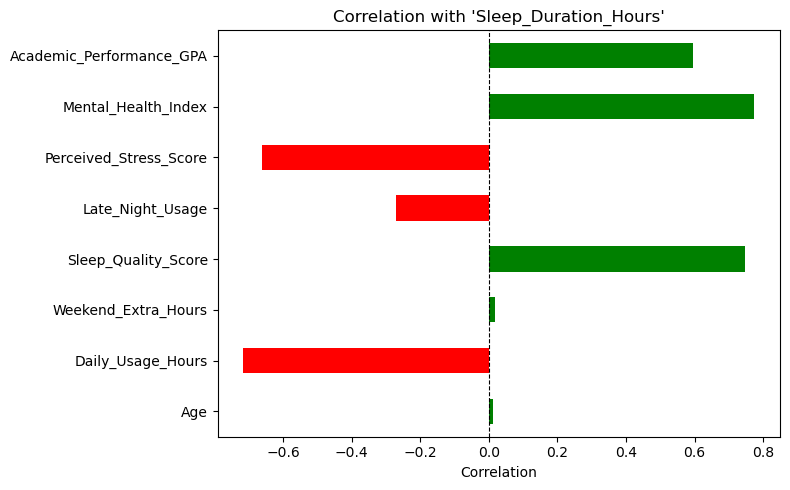

In [46]:
# Visualize correlation only for "Sleep_Duration_hours"
target_corr = (
    correlation_matrix["Sleep_Duration_Hours"]
    .drop("Sleep_Duration_Hours")
)

plt.figure(figsize=(8, 5))
target_corr.plot(
    kind="barh", color=["red" if x < 0 else "green" for x in target_corr]
)

plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Correlation with 'Sleep_Duration_Hours'")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

<h2>3. Data preparation</h2>

In [49]:
#remove unnecessary columns
df = df_full.drop(columns=["Student_ID", "Gender", "Overall_Impact", "Academic_Level", "Age", "Perceived_Stress_Score", "Sleep_Quality_Score", "Mental_Health_Index"]).dropna().copy()

#turn boolean values to integers | TRUE = 1, FALSE = 0
df["Late_Night_Usage"] = (df["Late_Night_Usage"].map({False: 0, True: 1, "False": 0, "True": 1}).astype(int))

#One-Hot Encode all reamingn string values
df = pd.get_dummies(df, dtype=int)

df

,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Late_Night_Usage,Academic_Performance_GPA,Primary_Platform_Instagram,Primary_Platform_LinkedIn,Primary_Platform_Reddit,Primary_Platform_Snapchat,Primary_Platform_TikTok,Primary_Platform_X (Twitter),Primary_Platform_YouTube,Device_Type_Laptop/PC,Device_Type_Smartphone,Device_Type_Tablet,Social_Comparison_Frequency_Always,Social_Comparison_Frequency_Frequently,Social_Comparison_Frequency_Never,Social_Comparison_Frequency_Rarely,Social_Comparison_Frequency_Sometimes
0,7.5,1.5,5.9,1,2.73,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0
1,4.6,1.3,7.9,1,3.21,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2,10.9,1.7,5.2,1,3.00,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0
3,6.0,2.3,7.6,1,3.42,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
4,3.3,2.6,7.6,1,3.41,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,5.8,1.2,7.8,1,2.85,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1
4496,3.8,3.0,6.6,0,3.37,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0
4497,7.7,1.1,6.0,1,3.16,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4498,4.6,3.3,7.1,0,3.50,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1


In [50]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Sleep_Duration_Hours"]).copy()
y = df["Sleep_Duration_Hours"].copy()

#split features and targets to test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fits the scaler on training data (calculates mean and std) and transforms it
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# transforms test data using training parameters to prevent data leakage
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train_scaled.columns)

X_train_scaled.head()

,Daily_Usage_Hours,Weekend_Extra_Hours,Late_Night_Usage,Academic_Performance_GPA,Primary_Platform_Instagram,Primary_Platform_LinkedIn,Primary_Platform_Reddit,Primary_Platform_Snapchat,Primary_Platform_TikTok,Primary_Platform_X (Twitter),Primary_Platform_YouTube,Device_Type_Laptop/PC,Device_Type_Smartphone,Device_Type_Tablet,Social_Comparison_Frequency_Always,Social_Comparison_Frequency_Frequently,Social_Comparison_Frequency_Never,Social_Comparison_Frequency_Rarely,Social_Comparison_Frequency_Sometimes
0,-0.997905,-0.713220,0.832557,0.747843,-0.681000,-0.154457,-0.237508,-0.339887,-0.609012,-0.213741,2.073685,-0.387274,0.435174,-0.172211,-0.410173,-0.614507,-0.252356,-0.452933,1.357456
1,-0.465909,1.177249,0.832557,0.900609,-0.681000,-0.154457,-0.237508,-0.339887,1.642003,-0.213741,-0.482233,-0.387274,0.435174,-0.172211,2.437995,-0.614507,-0.252356,-0.452933,-0.736672
2,0.788083,-1.294903,0.832557,-2.129245,-0.681000,-0.154457,-0.237508,-0.339887,1.642003,-0.213741,-0.482233,-0.387274,0.435174,-0.172211,-0.410173,-0.614507,-0.252356,2.207833,-0.736672
3,-0.237910,-2.022006,-1.201119,-0.474282,-0.681000,-0.154457,-0.237508,-0.339887,1.642003,-0.213741,-0.482233,-0.387274,0.435174,-0.172211,-0.410173,-0.614507,-0.252356,-0.452933,1.357456
4,-0.465909,-0.276958,0.832557,-0.805275,1.468428,-0.154457,-0.237508,-0.339887,-0.609012,-0.213741,-0.482233,-0.387274,0.435174,-0.172211,-0.410173,1.627320,-0.252356,-0.452933,-0.736672


<h2>4. Modeling</h2>

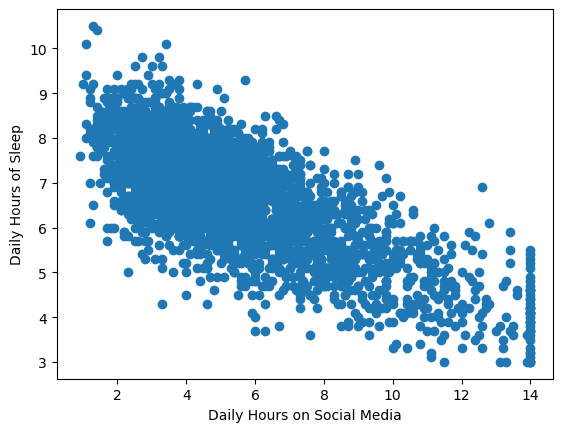

In [57]:
plt.scatter(X_train["Daily_Usage_Hours"], y_train)
plt.xlabel('Daily Hours on Social Media')
plt.ylabel('Daily Hours of Sleep')
plt.show()

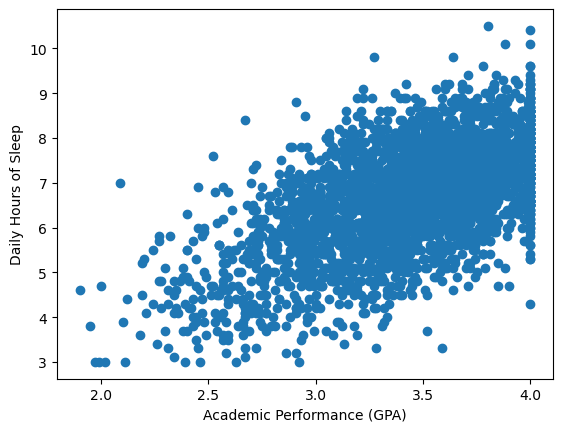

In [58]:
plt.scatter(X_train["Academic_Performance_GPA"], y_train)
plt.xlabel('Academic Performance (GPA)')
plt.ylabel('Daily Hours of Sleep')
plt.show()

<b>Model</b>

A Linear Regression model was selected to predict `Sleep_Duration_Hours`, as the target variable is continuous. The data was split into 70% training and 30% test data, and the features were standardized using `StandardScaler` using test_size=0.3 and random_state=123. So the model was trained using the scaled training data.

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [61]:
y_pred = model.predict(X_test_scaled)

In [62]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(f"Mean absolute error: {mae:.2f} hours")

Mean absolute error: 0.66 hours


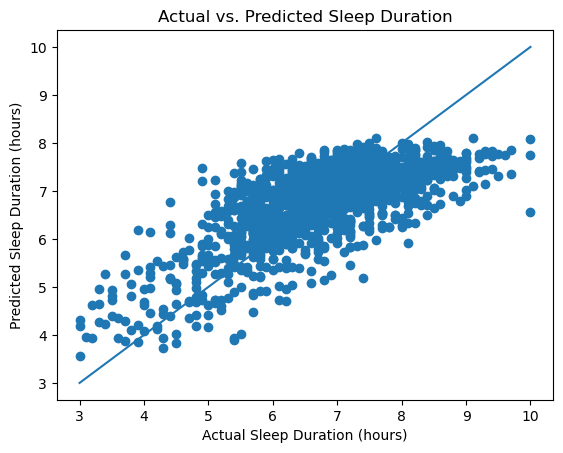

In [63]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(y_test.min(), y_test.max())
ys = xs

plt.plot(xs, ys)
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sleep Duration (hours)")
plt.ylabel("Predicted Sleep Duration (hours)")
plt.title("Actual vs. Predicted Sleep Duration")

plt.show()

The model was evaluated using Mean Absolute Error (MAE) on the unseen test data. The Linear Regression model achieved an MAE of **0.66 hours**, meaning that the predictions were on average approximately 40 minutes from the actual sleep duration. The model performed reasonably well. Therefore, Linear Regression was selected as the final model.

Additionally, we can test how social media usage correlates with GPA when controlling for sleep. For example, between students who get the same amount of sleep but have different social media usage hours.

In [67]:
X = df[["Daily_Usage_Hours", "Sleep_Duration_Hours"]]
y = df["Academic_Performance_GPA"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=123
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Intercept:", model.intercept_)
print("Social media coefficient:", model.coef_[0])
print("Sleep coefficient:", model.coef_[1])
# R² is an evaluation between 0 and 1 of how well the chosen variables explain variations in GPA
print("R²:", model.score(X_test_scaled, y_test))

Intercept: 3.426278317152103
Social media coefficient: -0.23164184490668638
Sleep coefficient: 0.06622680597771187
R²: 0.5209459735656292


The models predicts a GPA average of ~3.43 for students with average daily social media usage and average sleep duration. The social me

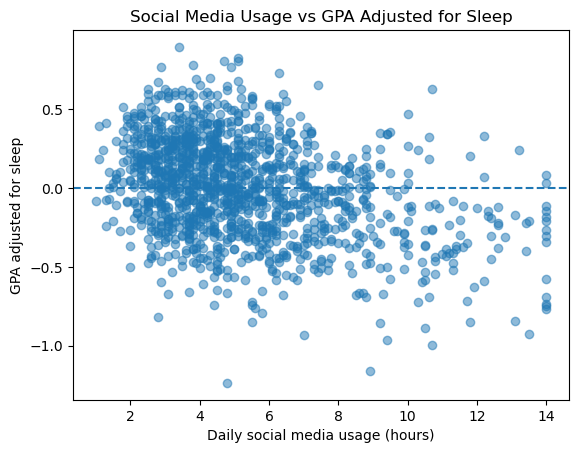

In [70]:
model.fit(
    X_train[["Sleep_Duration_Hours"]],
    y_train
)

# Predict GPA based on sleep
gpa_pred_sleep = model.predict(
    X_test[["Sleep_Duration_Hours"]]
)

# GPA remaining after accounting for sleep
gpa_adjusted = y_test - gpa_pred_sleep

# Plot
plt.scatter(
    X_test["Daily_Usage_Hours"],
    gpa_adjusted,
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Daily social media usage (hours)")
plt.ylabel("GPA adjusted for sleep")
plt.title("Social Media Usage vs GPA Adjusted for Sleep")

plt.show()

<h2>5. Evaluation</h2>

The original goal was to investigate whether students sleep duration could be predicted based on to their used device, social platform and usage hours/timing.

The final model was able to predict sleep duration with an average error of approximately 40 minutes. This suggests that the selected variables contain useful information about students sleep duration and that the original objective was at least partly achieved.

However, the model does not provide perfectly accurate predictions, so the results should be considered as an indications in the data, rather than an exact prediction.

### Interpretation and limitations

The results suggest that social media usage patterns can help predict students' sleep duration. However, the model cannot determine whether social media usage directly causes changes in sleep. Other factors, such as lifestyle, study schedules and personal habits, may also affect sleep duration.

The average prediction error of approximately 40 minutes shows that the model has some limitations. The results are useful for identifying general patterns, but they should not be treated as exact predictions for individual students. To evaluate the usefulness of the model, we compared it with a simple baseline that predicts the average sleep duration. The baseline model had an MAE of 0.95 hours (57 minutes), while Linear Regression achieved an MAE of 0.66 hours (approximately 40 minutes). 

This shows that Linear Regression performs better than simply predicting the average sleep duration. The improvement suggests that the selected features contain useful information for predicting students' sleep duration.

In [77]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

sleep_train, sleep_test = train_test_split(
    df["Sleep_Duration_Hours"],
    test_size=0.3,
    random_state=123
)

baseline_predictions = np.full(len(sleep_test), sleep_train.mean())
baseline_mae = mean_absolute_error(sleep_test, baseline_predictions)

print(f"Baseline MAE: {baseline_mae:.2f} hours")
print(f"Linear Regression MAE: {mae:.2f} hours")

Baseline MAE: 0.95 hours
Linear Regression MAE: 0.66 hours


<h2>6. Deployment</h2>